## Preprocess SFO NOAA Data

This notebook loads the combined parquet, inspects missing values, cleans dtypes, and saves to a final cleaned parquet.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parents[1]

COMBINED_PARQUET_PATH = REPO_ROOT / "Data_Extraction" / "santi" / "data" / "combined" / "sfo_noaa_combined.parquet"
CLEANED_DATA_DIR = REPO_ROOT / "Data_Preprocessing" / "santi" / "data" / "cleaned"
CLEANED_PARQUET_PATH = CLEANED_DATA_DIR / "sfo_noaa_cleaned.parquet"

CLEANED_DATA_DIR.mkdir(parents=True, exist_ok=True)

### Load combined data

In [2]:
weather_df = pd.read_parquet(COMBINED_PARQUET_PATH)

display(weather_df)

,STATION,Station_name,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,...,precipitation_24_hour_Quality_Code,precipitation_24_hour_Report_Type,precipitation_24_hour_Source_Code,precipitation_24_hour_Source_Station_ID,REM,REM_Measurement_Code,REM_Quality_Code,REM_Report_Type,REM_Source_Code,REM_Source_Station_ID
0,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,SYN08072494 32566 42915 10117 20044 30094 4012...,NaN,NaN,FM12,223.0,ICAO-KSFO
1,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET09812/31/21 16:56:03 METAR KSFO 010056Z 300...,NaN,NaN,FM15,343.0,724940-23234
2,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET09812/31/21 17:56:03 METAR KSFO 010156Z 300...,NaN,NaN,FM15,343.0,724940-23234
3,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET10112/31/21 18:56:03 METAR KSFO 010256Z 290...,NaN,NaN,FM15,343.0,724940-23234
4,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,MET09812/31/21 19:56:03 METAR KSFO 010356Z 310...,NaN,NaN,FM15,343.0,724940-23234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89171,USW00023234,SAN FRANCISCO INTL AP,2026-06-09 14:21:00,2026,6,9,14,21,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,KSFO 091421Z 34006KT 10SM FEW006 BKN013 OVC043...,NaN,NaN,FM16,413.0,ICAO-KSFO
89172,USW00023234,SAN FRANCISCO INTL AP,2026-06-09 14:56:00,2026,6,9,14,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,KSFO 091456Z 33007KT 10SM FEW006 BKN013 OVC045...,NaN,NaN,FM15,413.0,ICAO-KSFO
89173,USW00023234,SAN FRANCISCO INTL AP,2026-06-09 15:43:00,2026,6,9,15,43,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,KSFO 091543Z 33007KT 10SM FEW006 SCT014 BKN039...,NaN,NaN,FM16,413.0,ICAO-KSFO
89174,USW00023234,SAN FRANCISCO INTL AP,2026-06-09 15:56:00,2026,6,9,15,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,KSFO 091556Z 33006KT 10SM FEW006 SCT014 BKN039...,NaN,NaN,FM15,413.0,ICAO-KSFO


### Missing values by column

In [3]:
nan_count_by_column = (
    weather_df.isna()
    .sum()
    .rename("nan_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
nan_count_by_column["nan_percent"] = (
    nan_count_by_column["nan_count"] / len(weather_df) * 100
).round(2)

display(nan_count_by_column.sort_values("nan_count", ascending=False))

,column,nan_count,nan_percent
325,REM_Quality_Code,89176,100.0
324,REM_Measurement_Code,89176,100.0
306,precipitation_18_hour_Measurement_Code,89176,100.0
305,precipitation_18_hour,89176,100.0
304,precipitation_15_hour_Source_Station_ID,89176,100.0
...,...,...,...
6,Hour,0,0.0
5,Day,0,0.0
4,Month,0,0.0
1,Station_name,0,0.0


### Select columns

In [4]:
SELECTED_COLUMNS = [
    "DATE",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Minute",
    "LATITUDE",
    "LONGITUDE",
    "ELEVATION",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation",
]

missing_columns = [column for column in SELECTED_COLUMNS if column not in weather_df.columns]

selected_weather_df = weather_df.loc[:, SELECTED_COLUMNS].copy()

display(selected_weather_df)

,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,...,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,3.0,11.7,...,7.7,290.0,1012.4,1009.4,8.2,22000.0,NaN,800.0,NaN,NaN
1,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,...,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
2,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,...,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
3,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,...,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
4,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,...,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89171,2026-06-09 14:21:00,2026,6,9,14,21,37.6197,-122.3656,3.0,15.6,...,3.1,340.0,NaN,1015.4,14.6,396.0,1015.9,NaN,183.0,NaN
89172,2026-06-09 14:56:00,2026,6,9,14,56,37.6197,-122.3656,3.0,16.1,...,3.6,330.0,1016.0,1015.4,14.8,396.0,1015.9,NaN,183.0,NaN
89173,2026-06-09 15:43:00,2026,6,9,15,43,37.6197,-122.3656,3.0,16.1,...,3.6,330.0,NaN,1015.4,14.5,1189.0,1015.9,NaN,183.0,NaN
89174,2026-06-09 15:56:00,2026,6,9,15,56,37.6197,-122.3656,3.0,16.7,...,3.1,330.0,1015.8,1015.4,15.1,1189.0,1015.9,NaN,183.0,NaN


### Clean dtypes

In [5]:
cleaned_weather_df = selected_weather_df.copy()

cleaned_weather_df["DATE"] = pd.to_datetime(cleaned_weather_df["DATE"], errors="coerce")

numeric_columns = [column for column in SELECTED_COLUMNS if column != "DATE"]
for column in numeric_columns:
    cleaned_weather_df[column] = pd.to_numeric(cleaned_weather_df[column], errors="coerce")

cleaned_weather_df = cleaned_weather_df.sort_values("DATE", na_position="last").reset_index(drop=True)

dtype_summary = cleaned_weather_df.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"})
display(dtype_summary)
display(cleaned_weather_df.head())

,column,dtype
0,DATE,datetime64[us]
1,Year,int64
2,Month,int64
3,Day,int64
4,Hour,int64
5,Minute,int64
6,LATITUDE,float64
7,LONGITUDE,float64
8,ELEVATION,float64
9,temperature,float64


,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,...,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,3.0,11.7,...,7.7,290.0,1012.4,1009.4,8.2,22000.0,NaN,800.0,NaN,NaN
1,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,...,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
2,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,...,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
3,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,...,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
4,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,...,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0


In [6]:
nan_count_by_column = (
    cleaned_weather_df.isna()
    .sum()
    .rename("nan_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
nan_count_by_column["nan_percent"] = (
    nan_count_by_column["nan_count"] / len(cleaned_weather_df) * 100
).round(2)

display(nan_count_by_column.sort_values("nan_count", ascending=False))

,column,nan_count,nan_percent
22,precipitation,56049,62.85
21,sky_cover_summation_baseht_1,50082,56.16
20,sky_condition_baseht,46714,52.38
19,altimeter,44887,50.34
18,ceiling_height,43701,49.01
17,wet_bulb_temperature,41565,46.61
16,station_level_pressure,41563,46.61
15,sea_level_pressure,40957,45.93
14,wind_direction,35410,39.71
13,wind_speed,35397,39.69


### Normalize hourly data

In [7]:
# Decided not to drop all rows with any NaN due to NOAA data switch on 08/27/2025
# cleaned_weather_df = cleaned_weather_df.dropna()
# display(cleaned_weather_df)

In [8]:
# Keeping only rows with Minutes = 56 to preserve original hourly cadence
cleaned_weather_df = cleaned_weather_df[cleaned_weather_df["Minute"] == 56].reset_index(drop=True)
cleaned_weather_df

,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,ELEVATION,temperature,...,wind_speed,wind_direction,sea_level_pressure,station_level_pressure,wet_bulb_temperature,ceiling_height,altimeter,sky_condition_baseht,sky_cover_summation_baseht_1,precipitation
0,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,3.0,10.6,...,7.2,300.0,1012.8,1012.3,7.9,22000.0,1012.9,610.0,610.0,0.0
1,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,3.0,10.0,...,5.1,300.0,1013.3,1012.6,7.4,22000.0,1013.2,579.0,579.0,0.0
2,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,3.0,9.4,...,5.1,290.0,1014.0,1013.6,7.1,22000.0,1014.2,NaN,NaN,0.0
3,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,3.0,9.4,...,5.1,310.0,1014.6,1014.0,7.3,22000.0,1014.6,914.0,914.0,0.0
4,2022-01-01 04:56:00,2022,1,1,4,56,37.6197,-122.3656,3.0,8.9,...,2.6,330.0,1015.5,1015.0,7.1,22000.0,1015.6,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38727,2026-06-09 12:56:00,2026,6,9,12,56,37.6197,-122.3656,3.0,15.6,...,2.1,20.0,1014.8,1014.4,14.3,488.0,1014.9,NaN,183.0,NaN
38728,2026-06-09 13:56:00,2026,6,9,13,56,37.6197,-122.3656,3.0,15.6,...,3.6,310.0,1015.5,1015.1,14.6,457.0,1015.6,NaN,183.0,NaN
38729,2026-06-09 14:56:00,2026,6,9,14,56,37.6197,-122.3656,3.0,16.1,...,3.6,330.0,1016.0,1015.4,14.8,396.0,1015.9,NaN,183.0,NaN
38730,2026-06-09 15:56:00,2026,6,9,15,56,37.6197,-122.3656,3.0,16.7,...,3.1,330.0,1015.8,1015.4,15.1,1189.0,1015.9,NaN,183.0,NaN


### Correcting for observed sentinel-like values

In [9]:
# Encode 999 sentinel values in wind_direction as NaN
cleaned_weather_df.loc[cleaned_weather_df["wind_direction"] == 999, "wind_direction"] = np.nan


### Missingness before and after the NOAA source transition - 08/27/2025

,rows
missingness_period,
Before 2025-08-27,31989
On/after 2025-08-27,6743


missingness_period,Before 2025-08-27,On/after 2025-08-27
precipitation,1.8,91.3
station_level_pressure,1.3,73.1
wet_bulb_temperature,1.3,73.1
ceiling_height,0.2,41.8
sky_condition_baseht,14.3,37.1
sky_cover_summation_baseht_1,13.5,12.5
wind_direction,9.8,11.6
sea_level_pressure,0.0,0.0
wind_speed,0.0,0.0
dew_point_temperature,0.0,0.0


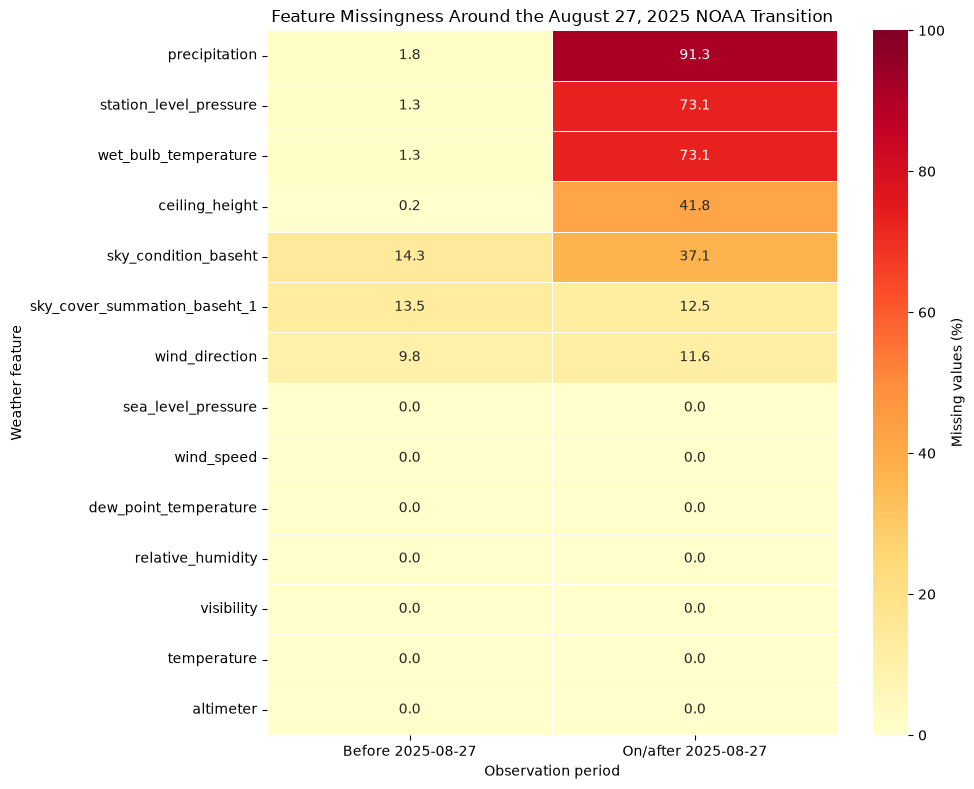

In [10]:
NOAA_TRANSITION_DATE = pd.Timestamp("2025-08-27")

missingness_columns = [
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "visibility",
    "wind_speed",
    "wind_direction",
    "sea_level_pressure",
    "station_level_pressure",
    "wet_bulb_temperature",
    "ceiling_height",
    "altimeter",
    "sky_condition_baseht",
    "sky_cover_summation_baseht_1",
    "precipitation",
]
period_order = ["Before 2025-08-27", "On/after 2025-08-27"]

missingness_comparison_df = cleaned_weather_df.assign(
    missingness_period=np.where(
        cleaned_weather_df["DATE"] < NOAA_TRANSITION_DATE,
        period_order[0],
        period_order[1],
    )
)

period_row_counts = (
    missingness_comparison_df["missingness_period"]
    .value_counts()
    .reindex(period_order)
    .rename("rows")
    .to_frame()
)
missingness_by_period = (
    missingness_comparison_df
    .groupby("missingness_period")[missingness_columns]
    .agg(lambda values: values.isna().mean() * 100)
    .T
    .reindex(columns=period_order)
    .sort_values(period_order[1], ascending=False)
)

display(period_row_counts)
display(missingness_by_period.round(1))

plt.figure(figsize=(10, 8))
sns.heatmap(
    missingness_by_period,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Missing values (%)"},
)
plt.title("Feature Missingness Around the August 27, 2025 NOAA Transition")
plt.xlabel("Observation period")
plt.ylabel("Weather feature")
plt.tight_layout()
plt.show()


### Summary check

In [11]:
nan_count_by_column = (
    cleaned_weather_df.isna()
    .sum()
    .rename("nan_count")
    .reset_index()
    .rename(columns={"index": "column"})
)
nan_count_by_column["nan_percent"] = (
    nan_count_by_column["nan_count"] / len(cleaned_weather_df) * 100
).round(2)

display(nan_count_by_column)

,column,nan_count,nan_percent
0,DATE,0,0.00
1,Year,0,0.00
2,Month,0,0.00
3,Day,0,0.00
4,Hour,0,0.00
5,Minute,0,0.00
6,LATITUDE,0,0.00
7,LONGITUDE,0,0.00
8,ELEVATION,0,0.00
9,temperature,3,0.01


### Save Cleaned Parquet

In [12]:
cleaned_weather_df.to_parquet(CLEANED_PARQUET_PATH, index=False)

print(f"Wrote cleaned NOAA data to: {CLEANED_PARQUET_PATH}")

Wrote cleaned NOAA data to: c:\Users\smeri\OneDrive\Desktop\MIDS Coursework\207-Summer26-FinalProject-MLModel\Data_Preprocessing\santi\data\cleaned\sfo_noaa_cleaned.parquet
